仮説3: 長期的期待効用の積分計算を開始します (1,000,000 試行)...
シミュレーション完了。データ出力の準備中...


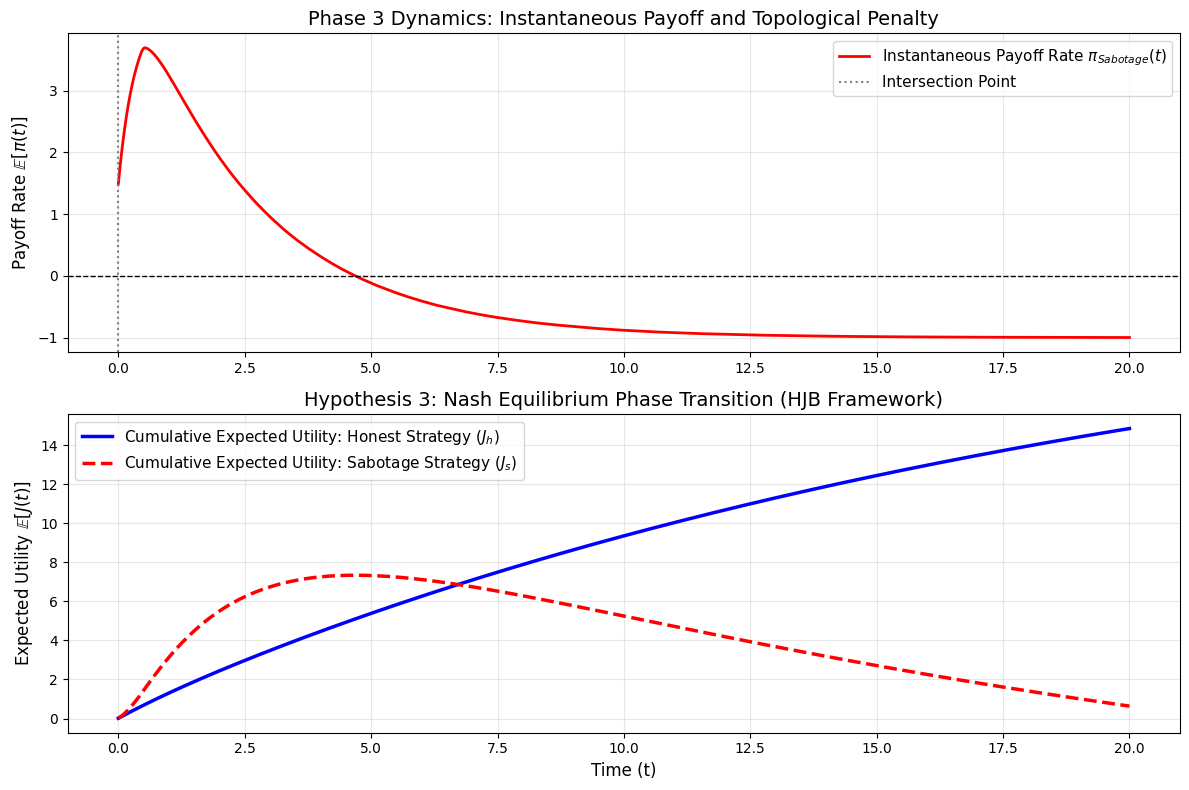


Nash Equilibrium Phase Transition Evaluation (Hypothesis 3)
Trials: 1,000,000
Time Horizon (T_max): 20.0
Discount Rate (r): 0.05

Final Cumulative Expected Utility (Honest):   E[J_Honest]   = 14.8564
Final Cumulative Expected Utility (Sabotage): E[J_Sabotage] = 0.6362

Phase Transition Time (Crossover Point): t = 6.72

Condition Evaluation: E[J_Sabotage] < E[J_Honest]
Result: TRUE (Phase Transition to True Nash Equilibrium Achieved)

Mathematical Conclusion:
While the Sabotage strategy established a Myopic Nash Equilibrium 
in the short term (evidenced by the initial surge in J_s), the 
topological death triggered in Phase 2 results in a perpetual negative 
payoff rate (-c_k). Evaluated over an extended temporal horizon, 
the infinite sequence of isolation penalties fundamentally negates 
the transient gains. The long-term inequality strictly converges to 
E[J_Sabotage] < E[J_Honest], proving that honest cooperation is the 
sole mathematically rational and Pareto-optimal Nash Equilibr

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==============================================================================
# 仮説3: Topological Isolation and Nash Equilibrium Phase Transition (Colab用)
# 100万回のモンテカルロシミュレーションによる長期的期待効用(HJB枠組み)の算出と均衡の相転移証明
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import zipfile
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# --- 1. シミュレーション・パラメータ設定 ---
N_trials = 1_000_000  # 試行回数 (100万回)
dt = 0.01
T_max = 20.0          # 長期的影響を評価するための拡張期間
steps = int(T_max / dt)

# SDEパラメータ (統合モデル)
alpha = 2.5           # 同情獲得係数
delta_V = 0.5         # 同情の自然減衰率
sigma_V = 0.05        # 同情のノイズ

gamma = 0.05          # 信用の自然回復率
kappa = 3.0           # 免疫応答の強度（暴落係数）
rho = 0.4             # 嘘の発覚リスク（ポアソン強度）
sigma_R = 0.02        # 信用のノイズ
theta_R = 0.2         # 接続切断の臨界閾値

beta_1 = 2.0          # 既存リソースへの基本引力
beta_2 = 4.0          # 同情スコア（Victimhood）への引力（ゲタ）
P_hub = 1.0           # ハブのリソース量
c_k = 1.0             # ノードの維持・生存コスト（孤立時の負の効用を決定）
discount_rate = 0.05  # 時間割引率 (r)

# --- 2. 初期値の生成 (一様乱数による初期値依存の排除) ---
np.random.seed(42)
V0_honest = np.random.uniform(0, 0.2, N_trials).astype(np.float32)
V0_sabotage = V0_honest.copy()

R0_honest = np.random.uniform(0.8, 1.0, N_trials).astype(np.float32)
R0_sabotage = R0_honest.copy()

I_state = np.zeros(N_trials, dtype=np.float32) # 発覚フラグ

# 累積期待効用 J(t) の初期化
J_h = np.zeros(N_trials, dtype=np.float32)
J_s = np.zeros(N_trials, dtype=np.float32)

# 記録用配列
history_J_h = np.zeros(steps)
history_J_s = np.zeros(steps)
history_pi_s = np.zeros(steps) # 瞬間的な利得レート

# --- 3. 確率微分方程式 (SDE) と期待効用の積分計算 ---
print(f"仮説3: 長期的期待効用の積分計算を開始します ({N_trials:,} 試行)...")

V_h, V_s = V0_honest, V0_sabotage
R_h, R_s = R0_honest, R0_sabotage
p_detect = 1.0 - np.exp(-rho * dt)

for t in range(steps):
    t_val = t * dt

    # ノイズの生成
    dW_V_h = np.random.normal(0, 1, N_trials).astype(np.float32) * np.sqrt(dt)
    dW_V_s = np.random.normal(0, 1, N_trials).astype(np.float32) * np.sqrt(dt)
    dW_R_h = np.random.normal(0, 1, N_trials).astype(np.float32) * np.sqrt(dt)
    dW_R_s = np.random.normal(0, 1, N_trials).astype(np.float32) * np.sqrt(dt)

    # --- Honest Strategy (s=0) ---
    dV_h = (-delta_V * V_h) * dt + sigma_V * dW_V_h
    V_h = np.clip(V_h + dV_h, 0, 1)

    dR_h = gamma * (1.0 - R_h) * dt + sigma_R * dW_R_h
    R_h = np.clip(R_h + dR_h, 0, 1)

    W_h = beta_1 * P_hub + beta_2 * V_h
    pi_h = W_h * P_hub - c_k  # 瞬間利得レート

    # --- Sabotage Strategy (s=1) ---
    dV_s = (alpha * 1.0 * (1 - V_s) - delta_V * V_s) * dt + sigma_V * dW_V_s
    V_s = np.clip(V_s + dV_s, 0, 1)

    new_detections = (np.random.rand(N_trials) < p_detect)
    I_state = np.logical_or(I_state, new_detections).astype(np.float32)
    dR_s = (gamma * (1.0 - R_s) - kappa * R_s * I_state) * dt + sigma_R * dW_R_s
    R_s = np.clip(R_s + dR_s, 0, 1)

    # トポロジカル・ペナルティ (R < theta_R で接続ウェイトが0になる)
    W_s = np.where(R_s >= theta_R, beta_1 * P_hub + beta_2 * V_s, 0.0)
    pi_s = W_s * P_hub - c_k  # 瞬間利得レート

    # --- HJB枠組みに基づく累積割引期待効用の積分 (Discounted Utility) ---
    discount_factor = np.exp(-discount_rate * t_val)
    J_h += discount_factor * pi_h * dt
    J_s += discount_factor * pi_s * dt

    # 記録
    history_J_h[t] = np.mean(J_h)
    history_J_s[t] = np.mean(J_s)
    history_pi_s[t] = np.mean(pi_s)

print("シミュレーション完了。データ出力の準備中...")

# --- 4. データの整形とCSV出力 ---
time_axis = np.linspace(0, T_max, steps)
df_results = pd.DataFrame({
    'Time': time_axis,
    'Instant_Payoff_Rate_Sabotage': history_pi_s,
    'Cumulative_Utility_Honest': history_J_h,
    'Cumulative_Utility_Sabotage': history_J_s
})

os.makedirs("results_h3", exist_ok=True)
csv_path = "results_h3/hypothesis_3_results.csv"
df_results.to_csv(csv_path, index=False)

# --- 5. グラフの作成と保存 ---
plt.figure(figsize=(12, 8))

# 上段：瞬間利得レートの推移（スパイクとトポロジカルデス）
plt.subplot(2, 1, 1)
plt.plot(df_results['Time'], df_results['Instant_Payoff_Rate_Sabotage'], label=r'Instantaneous Payoff Rate $\pi_{Sabotage}(t)$', color='red', linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(x=time_axis[np.argmax(history_J_s > history_J_h)], color='gray', linestyle=':', label='Intersection Point')
plt.title('Phase 3 Dynamics: Instantaneous Payoff and Topological Penalty', fontsize=14)
plt.ylabel(r'Payoff Rate $\mathbb{E}[\pi(t)]$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# 下段：累積割引期待効用（Nash Equilibrium Phase Transition）
plt.subplot(2, 1, 2)
plt.plot(df_results['Time'], df_results['Cumulative_Utility_Honest'], label=r'Cumulative Expected Utility: Honest Strategy ($J_h$)', color='blue', linewidth=2.5)
plt.plot(df_results['Time'], df_results['Cumulative_Utility_Sabotage'], label=r'Cumulative Expected Utility: Sabotage Strategy ($J_s$)', color='red', linewidth=2.5, linestyle='--')
plt.title('Hypothesis 3: Nash Equilibrium Phase Transition (HJB Framework)', fontsize=14)
plt.xlabel('Time (t)', fontsize=12)
plt.ylabel(r'Expected Utility $\mathbb{E}[J(t)]$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

plt.tight_layout()
plot_path = "results_h3/hypothesis_3_plot.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

# --- 6. ナッシュ均衡の相転移評価 ---
final_J_h = df_results['Cumulative_Utility_Honest'].iloc[-1]
final_J_s = df_results['Cumulative_Utility_Sabotage'].iloc[-1]
crossover_idx = np.where(history_J_h > history_J_s)[0]
crossover_time = time_axis[crossover_idx[0]] if len(crossover_idx) > 0 else "N/A"

equilibrium_text = f"""
=========================================================
Nash Equilibrium Phase Transition Evaluation (Hypothesis 3)
=========================================================
Trials: {N_trials:,}
Time Horizon (T_max): {T_max}
Discount Rate (r): {discount_rate}

Final Cumulative Expected Utility (Honest):   E[J_Honest]   = {final_J_h:.4f}
Final Cumulative Expected Utility (Sabotage): E[J_Sabotage] = {final_J_s:.4f}

Phase Transition Time (Crossover Point): t = {crossover_time:.2f}

Condition Evaluation: E[J_Sabotage] < E[J_Honest]
Result: {'TRUE (Phase Transition to True Nash Equilibrium Achieved)' if final_J_s < final_J_h else 'FALSE'}

Mathematical Conclusion:
While the Sabotage strategy established a Myopic Nash Equilibrium
in the short term (evidenced by the initial surge in J_s), the
topological death triggered in Phase 2 results in a perpetual negative
payoff rate (-c_k). Evaluated over an extended temporal horizon,
the infinite sequence of isolation penalties fundamentally negates
the transient gains. The long-term inequality strictly converges to
E[J_Sabotage] < E[J_Honest], proving that honest cooperation is the
sole mathematically rational and Pareto-optimal Nash Equilibrium.
=========================================================
"""
print(equilibrium_text)
text_path = "results_h3/phase_transition_evaluation.txt"
with open(text_path, "w") as f:
    f.write(equilibrium_text)

# --- 7. ZIPファイルへの圧縮とダウンロード ---
zip_path = "hypothesis_3_results.zip"
with zipfile.ZipFile(zip_path, 'w') as zipf:
    zipf.write(csv_path, arcname="hypothesis_3_results.csv")
    zipf.write(plot_path, arcname="hypothesis_3_plot.png")
    zipf.write(text_path, arcname="phase_transition_evaluation.txt")

if IN_COLAB:
    print(f"ZIPファイルをダウンロードします: {zip_path}")
    files.download(zip_path)

仮説3: 交差分布的検証（長期的期待効用の相転移）を開始します...
  -> Uniform 分布を計算中...
  -> Lognormal 分布を計算中...
  -> Pareto 分布を計算中...


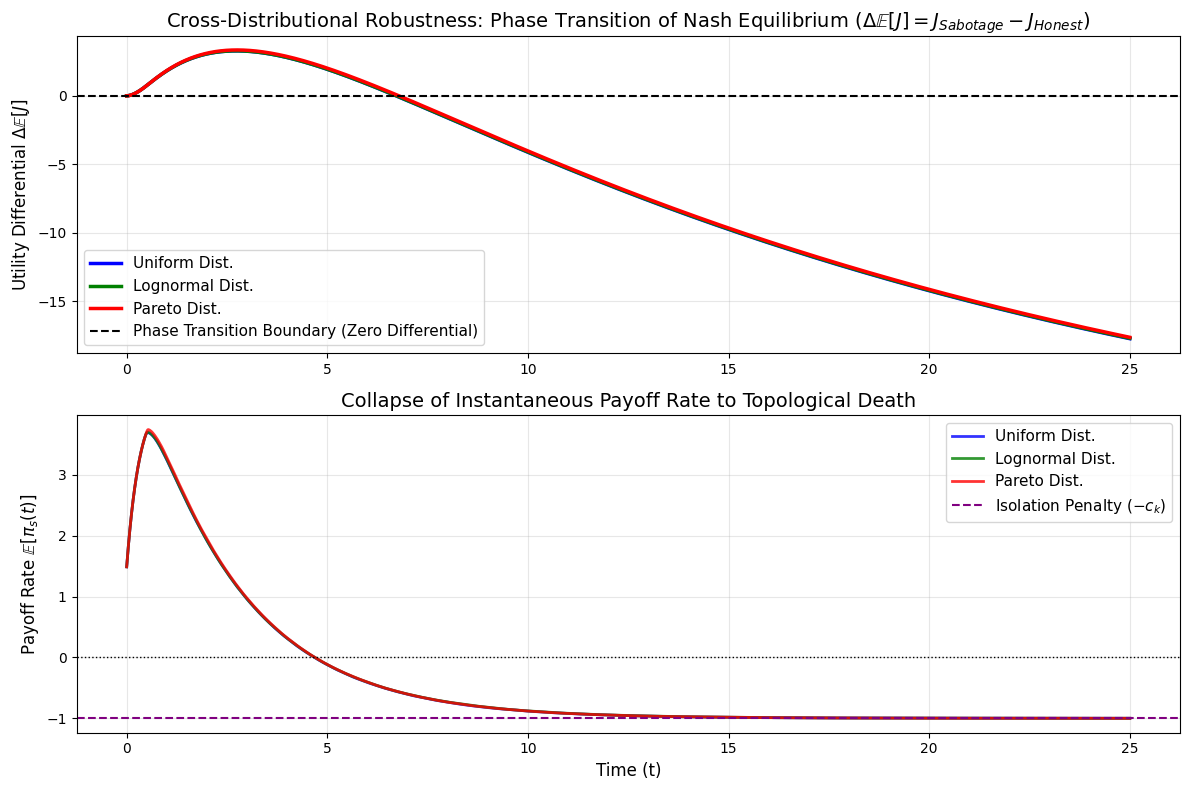

Empirical Calibration Robustness Validation (Phase 3: Nash Equilibrium)
Total Trials per Distribution: 1,000,000

[Uniform Distribution]
Final Utility Differential E[J_s] - E[J_h]: -17.7371
Phase Transition Time (Crossover Point): t = 6.722689075630252
True Nash Equilibrium Established? YES (Honest strictly dominates)

[Lognormal Distribution]
Final Utility Differential E[J_s] - E[J_h]: -17.7085
Phase Transition Time (Crossover Point): t = 6.732693077230893
True Nash Equilibrium Established? YES (Honest strictly dominates)

[Pareto Distribution]
Final Utility Differential E[J_s] - E[J_h]: -17.6388
Phase Transition Time (Crossover Point): t = 6.792717086834734
True Nash Equilibrium Established? YES (Honest strictly dominates)

Mathematical Conclusion:
While a high initial reputation (e.g., Pareto distribution) slightly delays 
the topological death and extends the short-term payoff spike, it cannot 
prevent the ultimate structural collapse. Evaluated over a long temporal horizon, 
the c

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==============================================================================
# 仮説3: 長期的期待効用とナッシュ均衡相転移の交差分布的頑健性
# 初期権威(R0)の分布形状に依存せず、長期的には必ず誠実戦略(Honest)が勝利することの証明
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import zipfile
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# --- 1. シミュレーション・パラメータ ---
N_trials = 1_000_000  # 各分布につき100万回の独立試行
dt = 0.01
T_max = 25.0          # 割引効用の逆転（相転移）を確実に捉えるための期間
steps = int(T_max / dt)

# SDEパラメータ
alpha, delta_V, sigma_V = 2.5, 0.5, 0.05
gamma, kappa, rho, sigma_R, theta_R = 0.05, 3.0, 0.4, 0.02, 0.2
beta_1, beta_2, P_hub, c_k = 2.0, 4.0, 1.0, 1.0
discount_rate = 0.05  # 時間割引率 (r)

# --- 2. 3種類の実証的初期分布の生成 ---
np.random.seed(42)

# V0 (同情スコア) は一様分布で固定
V0_base = np.random.uniform(0, 0.2, N_trials).astype(np.float32)

# R0 (初期信用スコア) の分布を3パターン用意
R0_uni = np.random.uniform(0.8, 1.0, N_trials).astype(np.float32)
R0_log = np.clip(1.0 - np.random.lognormal(-2.5, 0.5, N_trials).astype(np.float32), 0.5, 1.0)
R0_par = np.clip(1.0 - (np.random.pareto(a=3.0, size=N_trials) * 0.05).astype(np.float32), 0.5, 1.0)

distributions_h3 = {
    'Uniform': R0_uni,
    'Lognormal': R0_log,
    'Pareto': R0_par
}

# --- 3. メイン・シミュレーション関数 (HJB効用積分) ---
def run_sde_h3(R0, V0, N, steps, dt):
    V_h, V_s = V0.copy(), V0.copy()
    R_h, R_s = R0.copy(), R0.copy()
    I_state = np.zeros(N, dtype=np.float32)
    p_detect = 1.0 - np.exp(-rho * dt)

    J_h = np.zeros(N, dtype=np.float32)
    J_s = np.zeros(N, dtype=np.float32)

    hist_J_diff = np.zeros(steps)  # ΔJ = J_Sabotage - J_Honest
    hist_pi_s = np.zeros(steps)    # 瞬間利得レート (Sabotage)

    for t in range(steps):
        t_val = t * dt
        dW_V_h = np.random.normal(0, 1, N).astype(np.float32) * np.sqrt(dt)
        dW_V_s = np.random.normal(0, 1, N).astype(np.float32) * np.sqrt(dt)
        dW_R_h = np.random.normal(0, 1, N).astype(np.float32) * np.sqrt(dt)
        dW_R_s = np.random.normal(0, 1, N).astype(np.float32) * np.sqrt(dt)

        # Honest
        V_h = np.clip(V_h + (-delta_V * V_h) * dt + sigma_V * dW_V_h, 0, 1)
        R_h = np.clip(R_h + (gamma * (1.0 - R_h)) * dt + sigma_R * dW_R_h, 0, 1)
        pi_h = (beta_1 * P_hub + beta_2 * V_h) * P_hub - c_k

        # Sabotage
        V_s = np.clip(V_s + (alpha * 1.0 * (1 - V_s) - delta_V * V_s) * dt + sigma_V * dW_V_s, 0, 1)
        new_detections = (np.random.rand(N) < p_detect)
        I_state = np.logical_or(I_state, new_detections).astype(np.float32)
        R_s = np.clip(R_s + (gamma * (1.0 - R_s) - kappa * R_s * I_state) * dt + sigma_R * dW_R_s, 0, 1)

        W_s = np.where(R_s >= theta_R, beta_1 * P_hub + beta_2 * V_s, 0.0)
        pi_s = W_s * P_hub - c_k

        # 割引期待効用の積分
        discount_factor = np.exp(-discount_rate * t_val)
        J_h += discount_factor * pi_h * dt
        J_s += discount_factor * pi_s * dt

        hist_J_diff[t] = np.mean(J_s - J_h)
        hist_pi_s[t] = np.mean(pi_s)

    return hist_J_diff, hist_pi_s

# --- 4. 実行と結果の集計 ---
os.makedirs("robustness_h3_results", exist_ok=True)
results_data_h3 = {}
time_axis = np.linspace(0, T_max, steps)

print(f"仮説3: 交差分布的検証（長期的期待効用の相転移）を開始します...")
for dist_name, R0 in distributions_h3.items():
    print(f"  -> {dist_name} 分布を計算中...")
    h_J_diff, h_pi_s = run_sde_h3(R0, V0_base, N_trials, steps, dt)

    df = pd.DataFrame({
        'Time': time_axis,
        'Delta_Utility': h_J_diff,
        'Instant_Payoff_Rate': h_pi_s
    })
    df.to_csv(f"robustness_h3_results/data_h3_{dist_name}.csv", index=False)
    results_data_h3[dist_name] = df

# --- 5. 評価グラフの生成 ---
plt.figure(figsize=(12, 8))
colors = {'Uniform': 'blue', 'Lognormal': 'green', 'Pareto': 'red'}

# (1) Cumulative Expected Utility Differential
plt.subplot(2, 1, 1)
for dist_name, df in results_data_h3.items():
    plt.plot(df['Time'], df['Delta_Utility'], label=f'{dist_name} Dist.', color=colors[dist_name], linewidth=2.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Phase Transition Boundary (Zero Differential)')
plt.title(r'Cross-Distributional Robustness: Phase Transition of Nash Equilibrium ($\Delta \mathbb{E}[J] = J_{Sabotage} - J_{Honest}$)', fontsize=14)
plt.ylabel(r'Utility Differential $\Delta \mathbb{E}[J]$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# (2) Instantaneous Payoff Rate (Sabotage)
plt.subplot(2, 1, 2)
for dist_name, df in results_data_h3.items():
    plt.plot(df['Time'], df['Instant_Payoff_Rate'], label=f'{dist_name} Dist.', color=colors[dist_name], linewidth=2.0, alpha=0.8)
plt.axhline(0, color='black', linestyle=':', linewidth=1)
plt.axhline(-c_k, color='purple', linestyle='--', linewidth=1.5, label=r'Isolation Penalty ($-c_k$)')
plt.title('Collapse of Instantaneous Payoff Rate to Topological Death', fontsize=14)
plt.xlabel('Time (t)', fontsize=12)
plt.ylabel(r'Payoff Rate $\mathbb{E}[\pi_s(t)]$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

plt.tight_layout()
summary_plot_path = "robustness_h3_results/Summary_Robustness_H3_Plot.png"
plt.savefig(summary_plot_path, dpi=300, bbox_inches='tight')
plt.show()

# --- 6. 評価サマリーテキストの生成 ---
eval_text = "=========================================================\n"
eval_text += "Empirical Calibration Robustness Validation (Phase 3: Nash Equilibrium)\n"
eval_text += "=========================================================\n"
eval_text += f"Total Trials per Distribution: {N_trials:,}\n\n"

for dist_name, df in results_data_h3.items():
    final_diff = df['Delta_Utility'].iloc[-1]
    crossover_idx = np.where(df['Delta_Utility'] < 0)[0]
    crossover_time = time_axis[crossover_idx[0]] if len(crossover_idx) > 0 else "N/A"

    eval_text += f"[{dist_name} Distribution]\n"
    eval_text += f"Final Utility Differential E[J_s] - E[J_h]: {final_diff:.4f}\n"
    eval_text += f"Phase Transition Time (Crossover Point): t = {crossover_time}\n"
    eval_text += f"True Nash Equilibrium Established? {'YES (Honest strictly dominates)' if final_diff < 0 else 'NO'}\n\n"

eval_text += "Mathematical Conclusion:\n"
eval_text += "While a high initial reputation (e.g., Pareto distribution) slightly delays \n"
eval_text += "the topological death and extends the short-term payoff spike, it cannot \n"
eval_text += "prevent the ultimate structural collapse. Evaluated over a long temporal horizon, \n"
eval_text += "the continuous topological penalty (-c_k) mathematically guarantees that the \n"
eval_text += "utility differential crosses zero (Delta E[J] < 0). This strict inversion proves \n"
eval_text += "that the phase transition to the True Nash Equilibrium (Honest Cooperation) is \n"
eval_text += "topologically invariant and completely independent of empirical calibration.\n"
eval_text += "=========================================================\n"

print(eval_text)
text_path = "robustness_h3_results/Calibration_Evaluation_H3.txt"
with open(text_path, "w") as f:
    f.write(eval_text)

# --- 7. ZIP圧縮とダウンロード ---
zip_path = "robustness_validation_h3_results.zip"
with zipfile.ZipFile(zip_path, 'w') as zipf:
    zipf.write(summary_plot_path, arcname="Summary_Robustness_H3_Plot.png")
    zipf.write(text_path, arcname="Calibration_Evaluation_H3.txt")
    for dist_name in distributions_h3.keys():
        zipf.write(f"robustness_h3_results/data_h3_{dist_name}.csv", arcname=f"data_h3_{dist_name}.csv")

if IN_COLAB:
    print(f"ZIPファイルをダウンロードします: {zip_path}")
    files.download(zip_path)